In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')
sns.set(font_scale=1.1)

from google.colab import files

In [ ]:
# upload heart.csv from your computer
uploaded=files.upload()

df=pd.read_csv("heart.csv")
df.head(10)

Saving heart.csv to heart (2).csv


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [ ]:
df.shape

(918, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
# quick descriptive statistics for numeric colums
df.describe().T # .T দিয়ে row and column swap করা যায়

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [ ]:
# Define Target and Feature Types
target_col="HeartDisease"

numueric_cols=["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]

categorical_cols=["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

print(target_col)
print(numueric_cols)
print(categorical_cols)

HeartDisease
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


# Missing Values and Basic Quality Checks

In [ ]:
# check missng vaues count per column
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
# look at some basic value ranges:
df[numueric_cols].agg(["min","max","mean","median"]).T

,min,max,mean,median
Age,28.0,77.0,53.510893,54.0
RestingBP,0.0,200.0,132.396514,130.0
Cholesterol,0.0,603.0,198.799564,223.0
FastingBS,0.0,1.0,0.233115,0.0
MaxHR,60.0,202.0,136.809368,138.0
Oldpeak,-2.6,6.2,0.887364,0.6


In [ ]:
for c in categorical_cols:
  print(c,df[c].unique())

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


# understanding distributions with Histograms and Boxplots

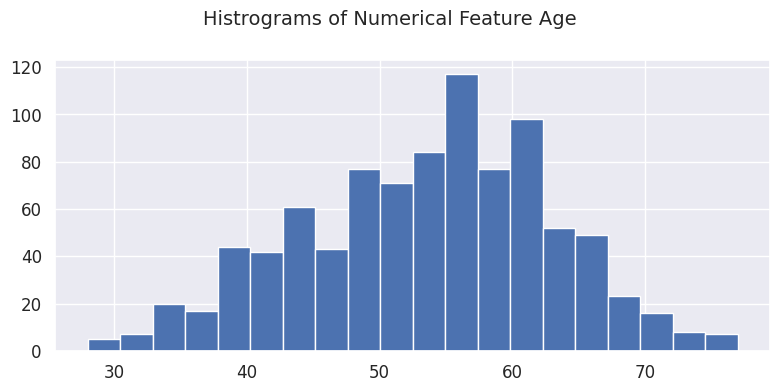

In [ ]:
# Histograms for numeric features
df["Age"].hist(bins=20, figsize=(8,4))
plt.suptitle("Histrograms of Numerical Feature Age", fontsize=14)
plt.tight_layout()
plt.show()

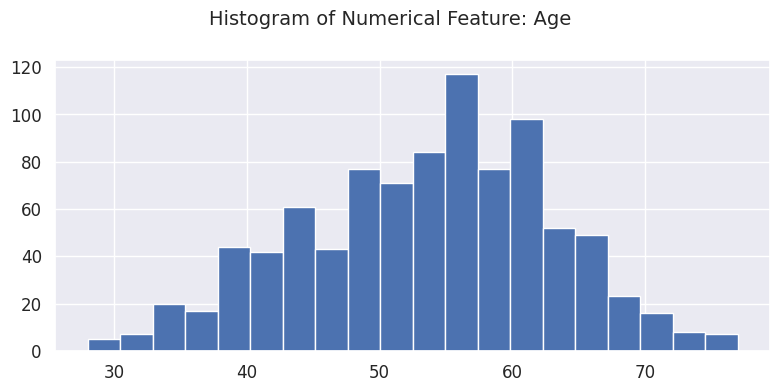

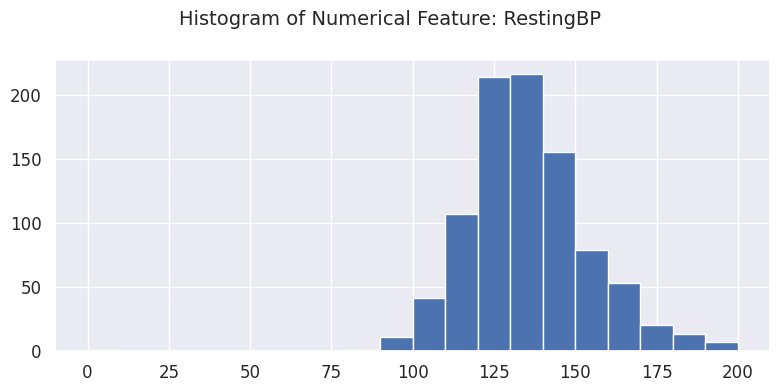

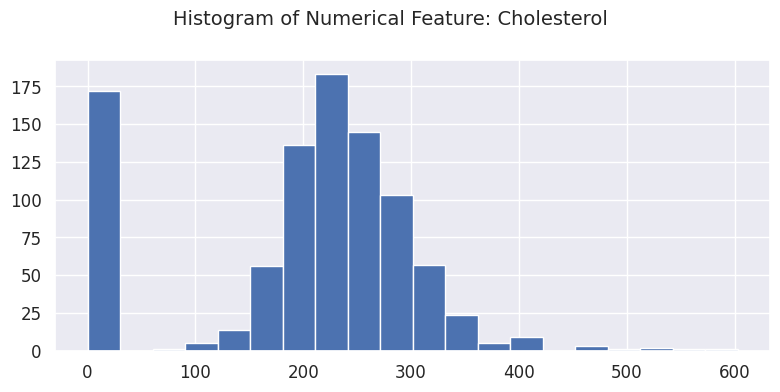

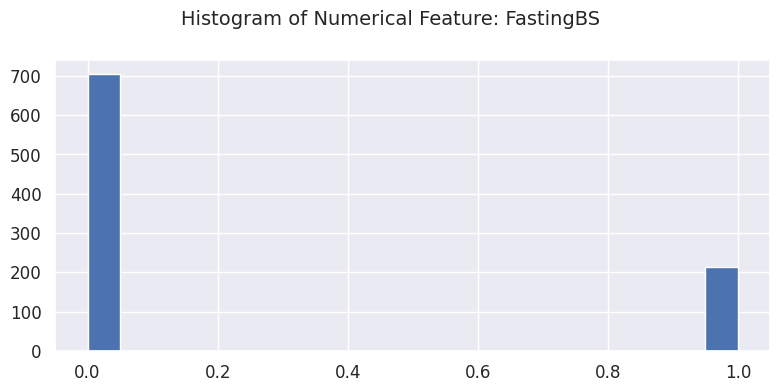

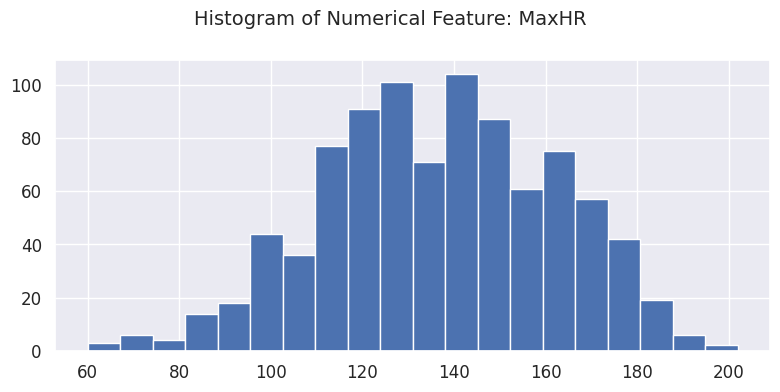

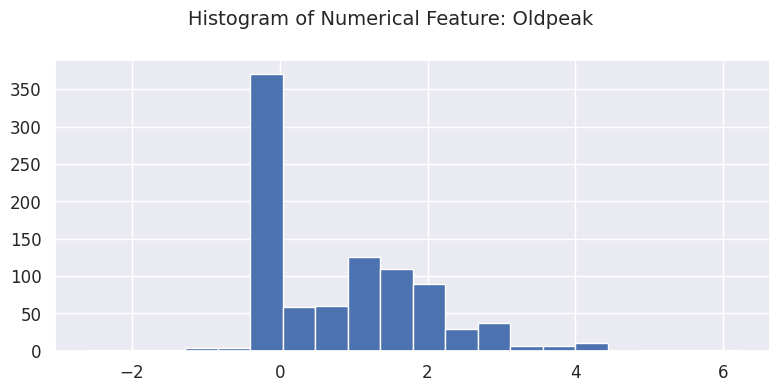

In [ ]:
for c in numueric_cols:
    df[c].hist(bins=20, figsize=(8,4))
    plt.suptitle(f"Histogram of Numerical Feature: {c}", fontsize=14)
    plt.tight_layout()
    plt.show()

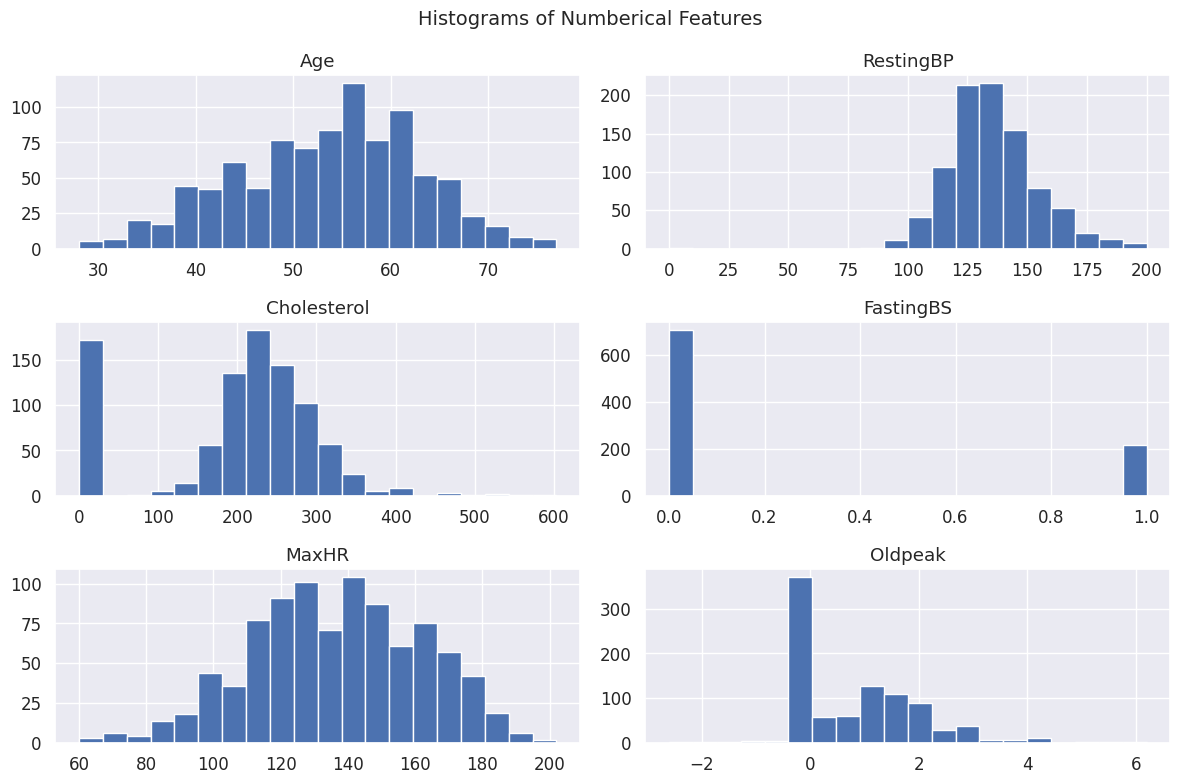

In [ ]:
# এক সাথে সব গুলা দেখা
df[numueric_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Histograms of Numberical Features", fontsize=14)
plt.tight_layout()
plt.show()

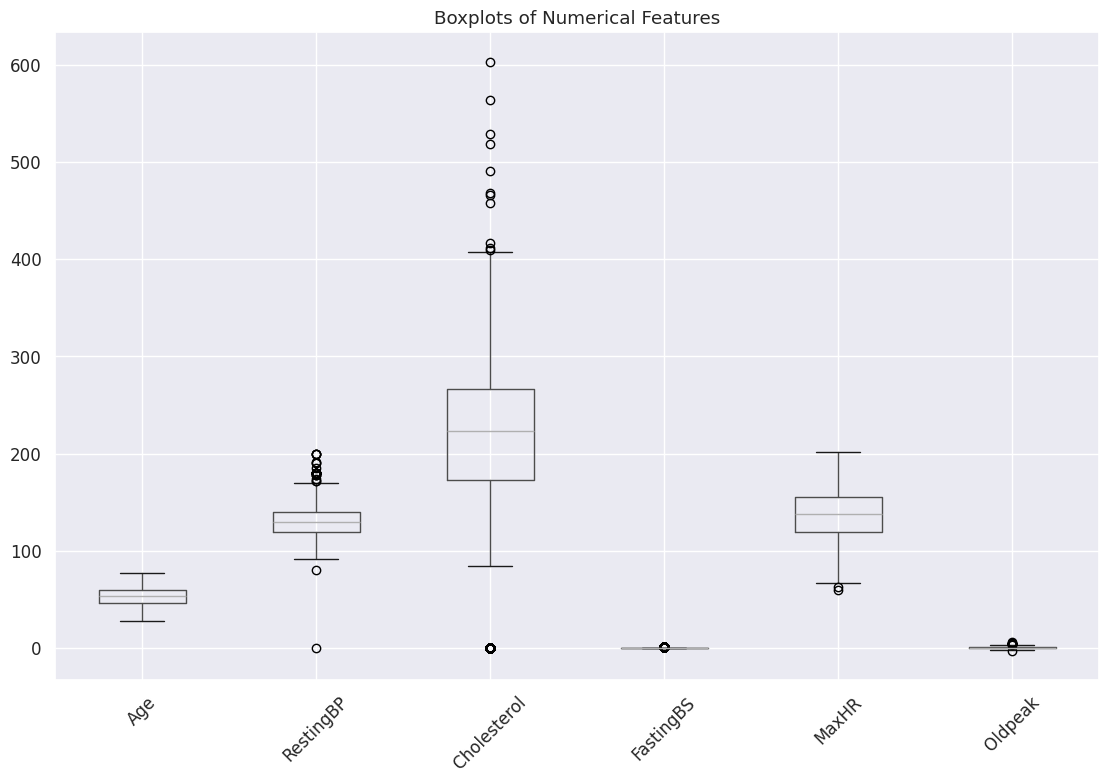

In [ ]:
# Boxplots to get a sense of spread and possible ouutliers
plt.figure(figsize=(12,8))
df[numueric_cols].boxplot()
plt.title("Boxplots of Numerical Features")  # font size আগেই দিয়ে আসছি,তাই আর দিচ্ছি না
plt.xticks(rotation=45)
plt.show()

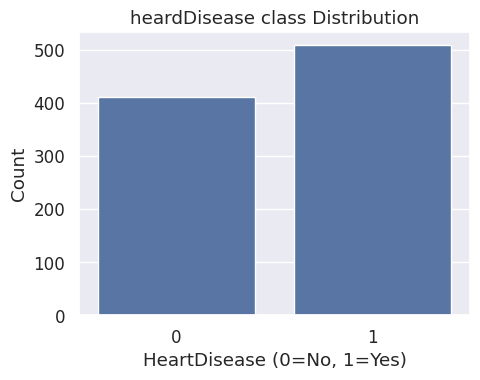

In [ ]:
# Target Distribuution and class imbalance
plt.figure(figsize=(5,4))
sns.countplot(x=df[target_col])
plt.title("heardDisease class Distribution")
plt.xlabel("HeartDisease (0=No, 1=Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
df[target_col].value_counts(normalize=True)

,proportion
HeartDisease,
1,0.553377
0,0.446623


# Categorical Feature Exploration

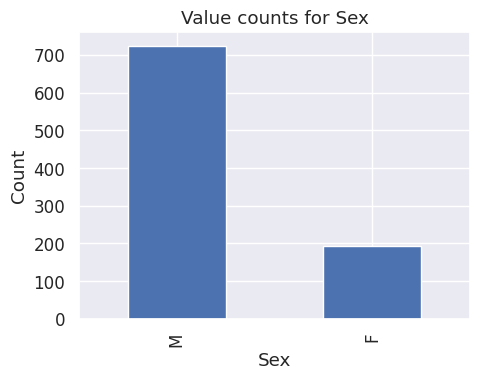

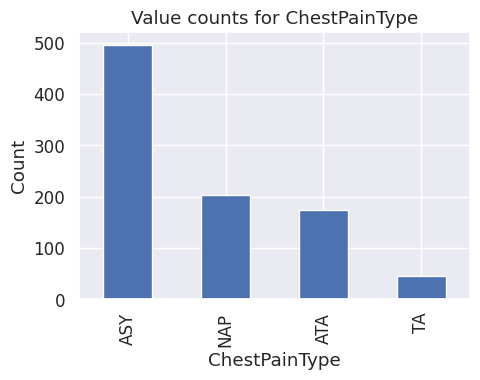

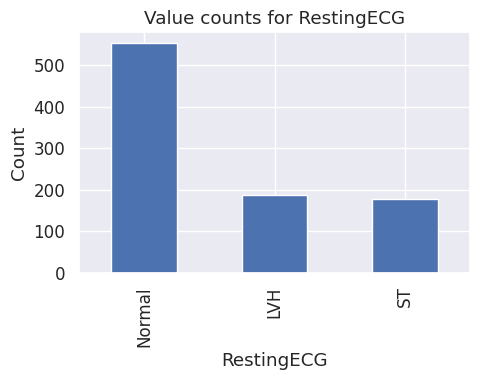

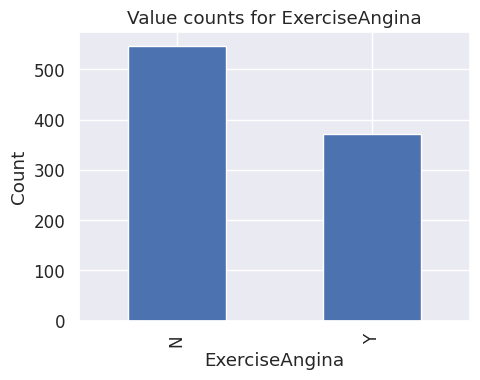

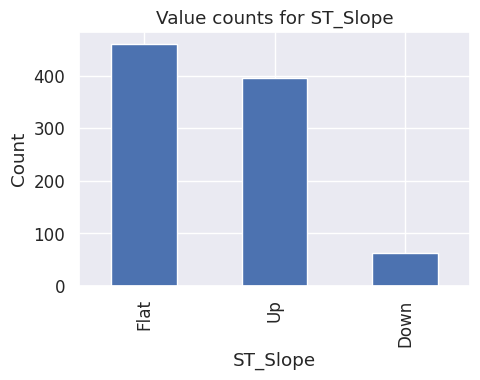

In [ ]:
 for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df[c].value_counts().plot(kind="bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  #plt.xlabel(c)
  plt.tight_layout()
  plt.show()

# Relationships Between Features and Target

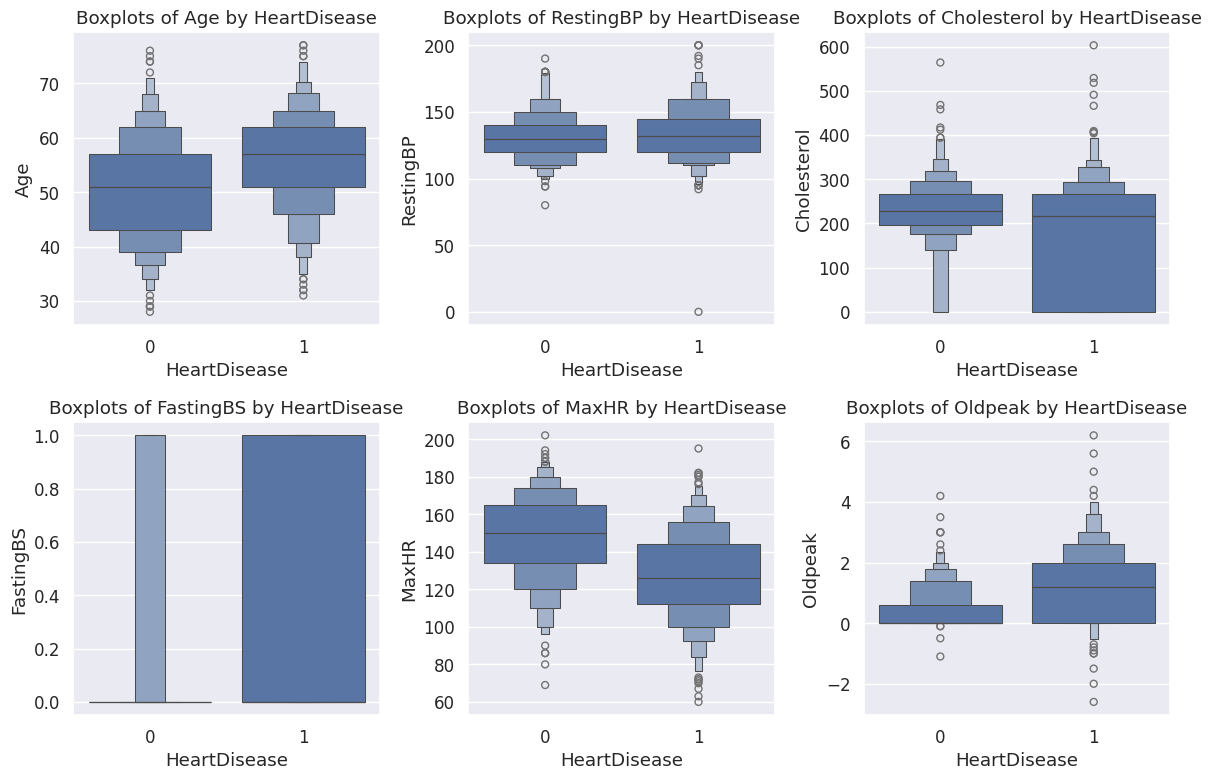

In [ ]:
# boxplots for numeric features split by heartDisease
plt.figure(figsize=(12,8))
for i, col in enumerate(numueric_cols,1):
  plt.subplot(2,3,i)
  sns.boxenplot(x=df[target_col],y=df[col])
  plt.title(f"Boxplots of {col} by HeartDisease")

plt.tight_layout()
plt.show()

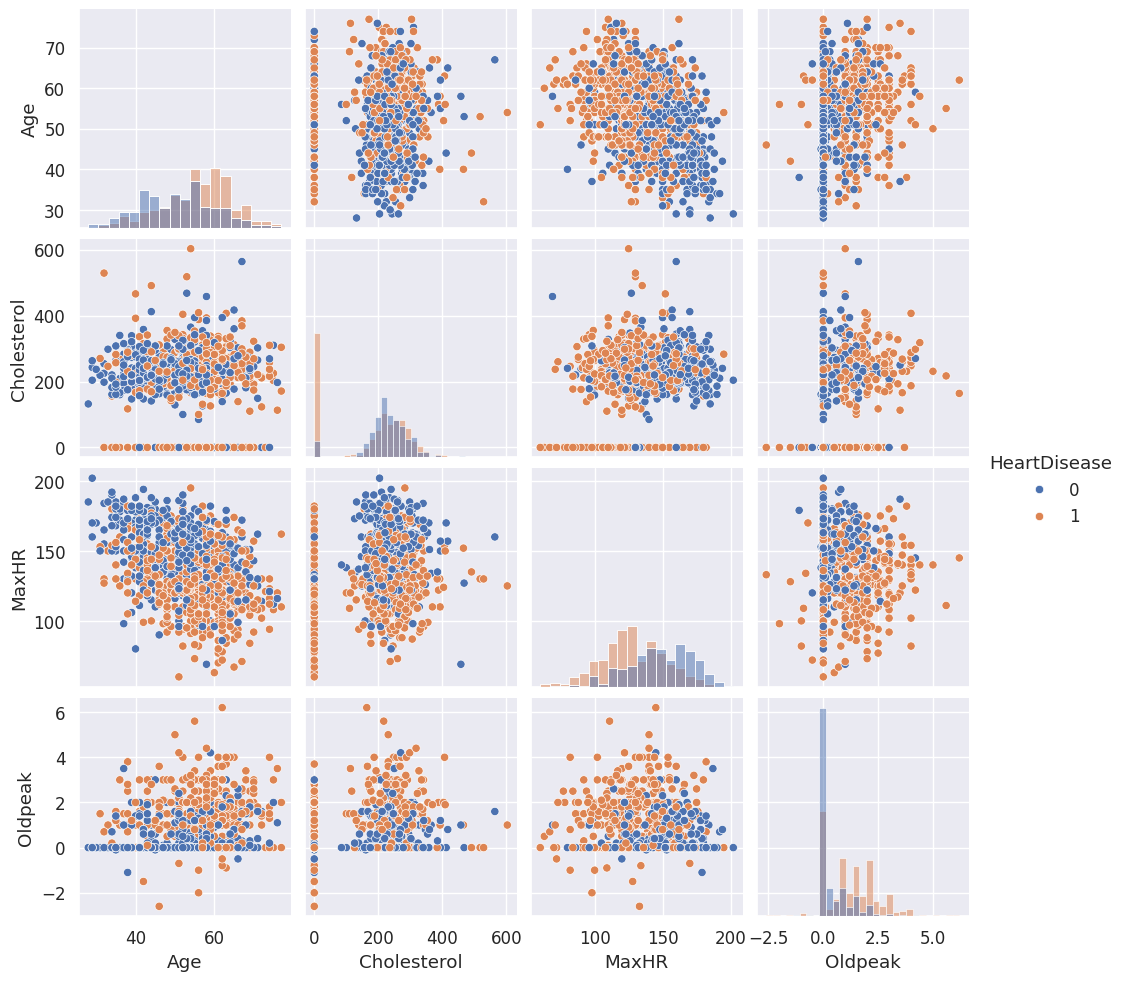

In [ ]:
# Pairplot for a subset of features
sns.pairplot(df[["Age", "Cholesterol", "MaxHR", "Oldpeak", "HeartDisease"]], hue="HeartDisease", diag_kind="hist")
plt.show()

# Correlation Matrix and Heatmap

## Numerical features

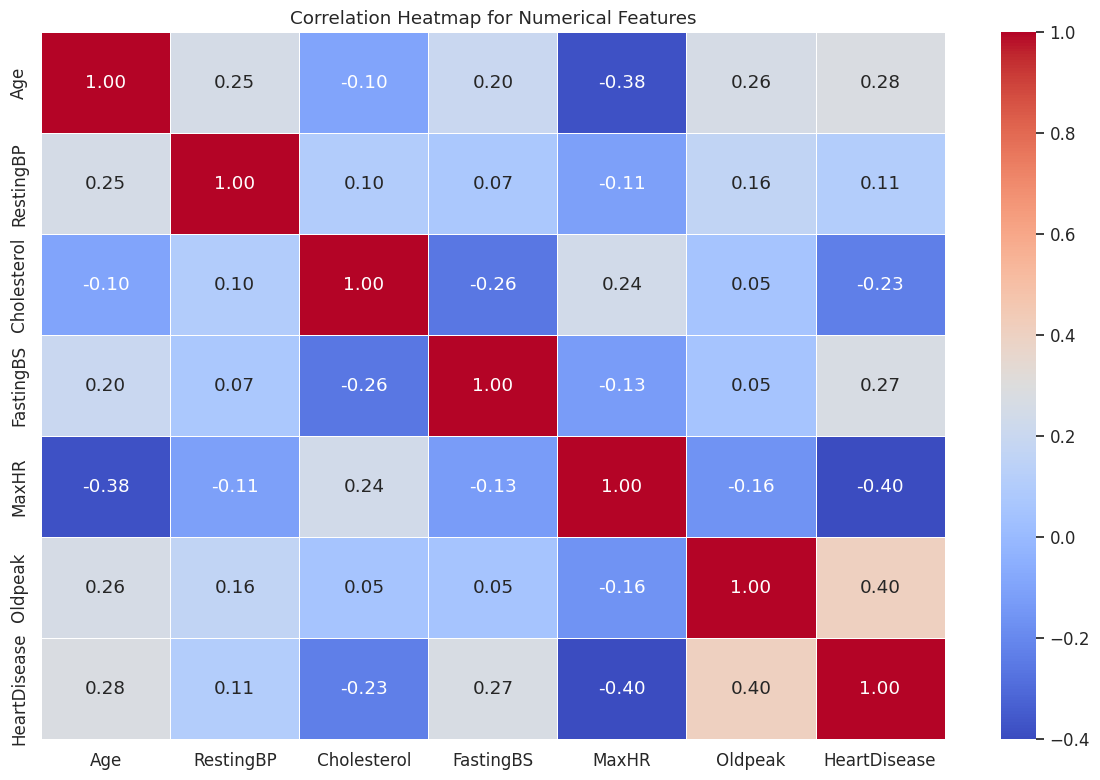

In [ ]:
corr_matrix=df[numueric_cols+ [target_col]].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix[target_col].sort_values(ascending=False)

,HeartDisease
HeartDisease,1.000000
Oldpeak,0.403951
Age,0.282039
FastingBS,0.267291
RestingBP,0.107589
Cholesterol,-0.232741
MaxHR,-0.400421


## Categorical features


Proportion of HeartDisease within Sex


HeartDisease,0,1
Sex,,
F,0.740933,0.259067
M,0.368276,0.631724


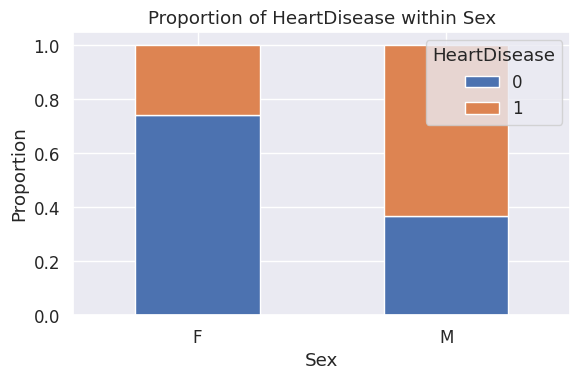


Proportion of HeartDisease within ChestPainType


HeartDisease,0,1
ChestPainType,,
ASY,0.209677,0.790323
ATA,0.861272,0.138728
NAP,0.645320,0.354680
TA,0.565217,0.434783


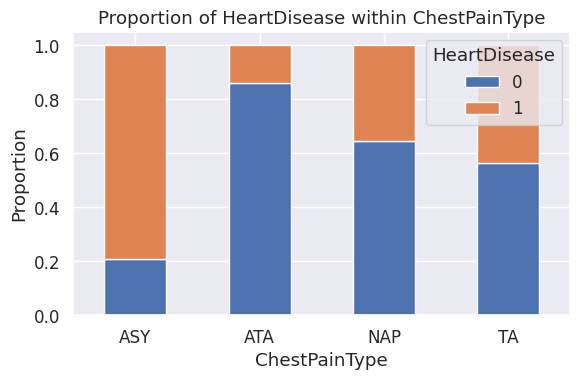


Proportion of HeartDisease within RestingECG


HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303


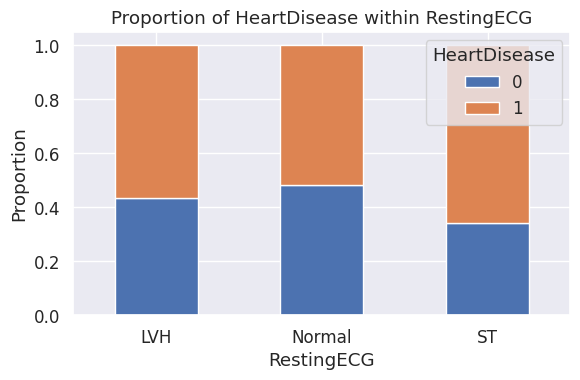


Proportion of HeartDisease within ExerciseAngina


HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752


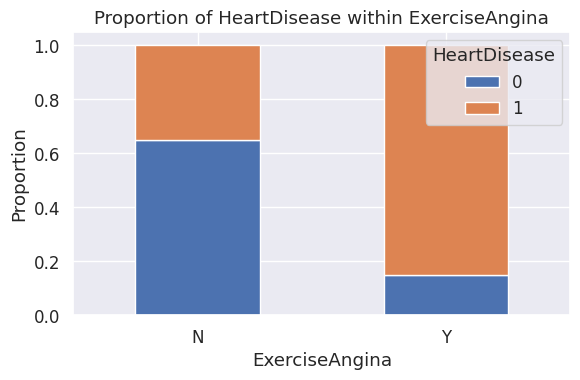


Proportion of HeartDisease within ST_Slope


HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


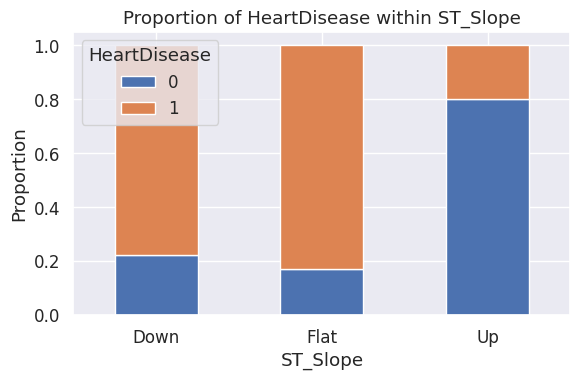

In [ ]:
for c in categorical_cols:
  ct = pd.crosstab(df[c], df[target_col], normalize="index")
  print(f"\nProportion of HeartDisease within {c}")
  display(ct)

  ct.plot(kind="bar", stacked=True, figsize=(6,4))
  plt.title(f"Proportion of HeartDisease within {c}")
  plt.ylabel("Proportion")
  plt.xticks(rotation=0)
  plt.tight_layout()
  plt.show()
